# 7강 실습: 데이터프레임과 시각화

`data/apicius/index.tsv`·`book.tsv`·`word-freq.txt`를 pandas 표로 다루고 seaborn으로 그린다.

- 이 노트북은 저장소 **맨 위**(`/workspaces/LDS2026`)에 두어야 `data/apicius/…` 경로가 맞는다.
- 처음 한 번은 터미널에서 `pip install pandas seaborn`을 실행한다. seaborn을 깔면 pandas와 matplotlib이 함께 딸려 온다.
- `book.tsv`는 「5. 두 표를 붙이고 묶기」 앞에서, `plots/` 폴더는 「8. 그림 남기기」 앞에서 터미널로 만든다.
- 커밋하기 전에는 [Restart] 후 [Run All]로 위에서 아래까지 한 번에 돌려 본다.

## 0. 준비

세 라이브러리를 불러온다. `pd`, `sns`, `plt`도 numpy의 `np`처럼 모두가 지키는 약칭이다.

- **pandas**: 표를 다루는 라이브러리. 이름은 *panel data*에서 왔다.
- **seaborn**: 표와 열 이름을 받아 통계 그림을 그리는 라이브러리
- **matplotlib**: seaborn이 실제로 그림을 그릴 때 쓰는 바탕 라이브러리. 저장처럼 seaborn이 못 하는 손질에 쓴다.

`sns.set_theme(style='whitegrid')`는 모든 그림을 흰 바탕에 눈금선으로 그리도록 정한다.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

## 1. 표를 표인 채로

**Series**는 numpy 배열 하나에 **색인**(index)을 붙인 것이다.

- `index=['가', '나', '다']`: 각 값에 이름표를 붙인다. `s['나']`처럼 이름으로 부를 수 있다.
- 출력 맨 아래의 `dtype: int64`처럼 자료형은 그대로 있다. 한 Series에는 여전히 한 자료형만 담긴다.

In [2]:
s = pd.Series([144, 82, 73],
              index=['가', '나', '다'])
print(s)
print(s['나'])

가    144
나     82
다     73
dtype: int64
82


**DataFrame**은 색인을 함께 쓰는 Series의 모음, 곧 표다. `pd.read_csv`로 파일을 표로 읽는다.

- 이름은 CSV지만 `sep`만 바꾸면 어떤 구분자든 읽는다. `sep='\t'`는 탭으로, 6강 `np.loadtxt`의 `delimiter`에 해당한다.
- `shape`는 `(행, 열)`이다. 머리글 행은 **저절로** 열 이름(`columns`)이 되어 499행 3열이 되었다.

6강에서 배열 셋으로 쪼개야 했던 표가 이름 하나(`df`) 아래에 함께 들어왔다.

In [3]:
df = pd.read_csv('data/apicius/index.tsv', sep='\t')
print(df.shape)
print(df.columns)

(499, 3)
Index(['number', 'title', 'words'], dtype='str')


`head(n)`은 앞의 n행을 보여 준다. 맨 왼쪽의 `0, 1, 2`가 색인이다.

셀의 마지막 식을 `df.head(3)`으로 두면 노트북이 칸이 그어진 표로 그려 준다. 여기서는 6강에서 정한 대로 `print`로 감싸 글자로 출력했다.

In [4]:
print(df.head(3))

   number                          title  words
0       1               FINE SPICED WINE    144
1       2  HONEY REFRESHER FOR TRAVELERS     82
2       3                 ROMAN VERMOUTH     73


`info()`는 표의 신상명세다. 열마다 이름, 비어 있지 않은 값의 수(`Non-Null Count`), 자료형(`Dtype`)을 보여 준다.

- `number`, `words`는 `int64`, `title`은 `str`이다. 6강의 배열로는 못 하던, 열마다 자료형이 다른 표다.
- **`title`만 498이다.** 499행 가운데 한 자리가 비어 있다. pandas는 빈 칸을 **결측값**(`NaN`)으로 표시해 세어 준다. 6강의 `np.loadtxt(..., dtype=str)`는 빈 칸을 빈 문자열 `''`로 읽어서 아무도 눈치채지 못했다.

`info()`는 결과를 스스로 출력하므로 `print`로 감싸지 않는다. 어느 레시피인지는 「5. 두 표를 붙이고 묶기」에서 찾는다.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   number  499 non-null    int64
 1   title   498 non-null    str  
 2   words   499 non-null    int64
dtypes: int64(2), str(1)
memory usage: 11.8 KB


`describe()`는 수치 열의 기술통계량을 한 번에 보여 준다. 개수, 평균, 표준편차, 최솟값, 사분위수(25%·50%·75%), 최댓값이다.

5강의 AWK와 6강의 numpy로 구한 값(499, 45.12, 34.77, 0 / 20 / 33 / 61 / 273)이 다 들어 있다.
pandas의 `std`는 **기본이 `ddof=1`**($n-1$)이다. numpy(기본 $n$)와 반대이니 조심한다.

In [6]:
print(df['words'].describe())

count    499.000000
mean      45.124248
std       34.774035
min        0.000000
25%       20.000000
50%       33.000000
75%       61.000000
max      273.000000
Name: words, dtype: float64


## 2. 열과 행 고르기

대괄호 **한 겹**과 **두 겹**은 다르다.

- `df['words']`: 열 **하나**를 꺼낸다 → Series
- `df[['number', 'words']]`: 안쪽 대괄호는 열 이름의 **목록**이다. 목록을 주면 표가 돌아온다 → DataFrame

`type(...)`은 자료형을 알려 주고, `.__name__`은 그 이름만 꺼낸다. 열 하나짜리 표가 필요하면 `df[['words']]`라고 쓴다.

In [7]:
print(type(df['words']).__name__)
print(type(df[['number', 'words']]).__name__)
print(df[['number', 'words']].head(3))

Series
DataFrame
   number  words
0       1    144
1       2     82
2       3     73


Series 안에는 6강의 배열이 들어 있다. 집계 메서드도, 불리언 마스크도 6강 그대로 통한다.

- `w.mean()`, `w.std()`, `w.median()`: 평균, 표준편차(`ddof=1`), 중앙값
- `w.values`: 속에 든 numpy 배열을 꺼낸다
- `w[w > 200]`: 마스크로 골라내기

새로 외울 것은 색인뿐이다.

In [8]:
w = df['words']
print(w.mean(), w.std(), w.median())
print(w.values[:5])
print(w[w > 200].values)

45.124248496993985 34.77403524607915 33.0
[144  82  73  82  23]
[206 273]


행을 고르는 두 가지 방법이다. `[행, 열]` 순서로 적는다.

- `loc`: 행은 **색인**으로, 열은 **이름**으로 부른다. 슬라이스의 끝값을 **포함**하므로 `0:2`가 세 개다.
- `iloc`: 둘 다 **자리 번호**로 부른다. 6강의 배열처럼 끝값을 빼므로 `0:2`가 두 개다.

지금은 색인이 0, 1, 2, …라 둘이 거의 같아 보인다. 정렬하거나 골라내고 나면 색인이 흩어져 둘이 완전히 달라진다.

In [9]:
print(df.loc[0, 'title'])
print(df.iloc[0, 1])
print(df.loc[0:2, 'words'].values)
print(df.iloc[0:2, 2].values)

FINE SPICED WINE
FINE SPICED WINE
[144  82  73]
[144  82]


## 3. 고르고 정렬하기

조건으로 행을 고른다. 마스크 하나가 **행 전체**를 고르므로 번호와 제목이 함께 딸려 온다.

6강에서는 마스크를 `numbers`와 `titles`에 따로 씌워야 했다. 왼쪽의 `140`, `185`는 원래 색인이고, 레시피 번호(`141`, `186`)와 하나씩 어긋난다.

In [10]:
print(df[df['words'] > 200])

     number                 title  words
140     141          APICIAN DISH    206
185     186  PEAS [supreme style]    273


6강의 마스크 세기와 조건 잇기를 pandas로 한다.

- `m.sum()`, `m.mean()`: `True`의 개수와 비율. 평균보다 짧은 레시피가 313개, 62.7%다.
- `df.query('20 <= words <= 61')`: 조건을 **문자열**로 적는다. 열 이름을 그냥 쓰고, 부등호를 이어 쓸 수 있다. `len(...)`으로 행 수를 센다.

같은 조건을 마스크로 쓰면 `df[(df['words'] >= 20) & (df['words'] <= 61)]`이다. `&`, `|`, `~`와 괄호는 6강 그대로다.

In [11]:
m = df['words'] < df['words'].mean()
print(m.sum(), f'{m.mean():.1%}')
print(len(df.query('20 <= words <= 61')))

313 62.7%
258


`sort_values('words')`는 `words` 열을 기준으로 **행을 통째로** 정렬한다. 기본은 작은 순이고, 큰 순은 `ascending=False`다.

색인 `219`가 제목과 함께 따라온 것이 그 증거다. 6강의 배열에서 `np.sort(words)`를 하면 `titles`는 제자리에 남아 짝이 어긋난다.

In [12]:
print(df.sort_values('words').head(3))

     number                                             title  words
219     220  FOR ROASTS: PEPPER, LOVAGE, CORIANDER, CARRAWAY,      0
202     203                                       BEANS SAUTÉ      6
307     308                                       FRIED BULBS      6


`nlargest(n, 열)`은 그 열의 값이 가장 큰 n행을 준다. `sort_values('words', ascending=False).head(4)`와 결과가 같고 더 짧다. 가장 작은 쪽은 `nsmallest`다.

6강의 `argmax`는 가장 긴 하나만 찾았다.

In [13]:
print(df.nlargest(4, 'words'))

     number                 title  words
185     186  PEAS [supreme style]    273
140     141          APICIAN DISH    206
173     174   MOVEABLE APPETIZERS    184
284     285          PIG'S PAUNCH    177


## 4. 열 만들기와 세기

없는 열 이름에 대입하면 열이 **새로 생긴다**. 여기서는 6강의 $z$-점수를 `z` 열로 만든다.

- 계산은 499행 전부에 한 번에 적용된다. `std()`는 pandas라서 `ddof=1`이다.
- `df['z'].abs() > 3`: 절댓값이 3보다 큰 행, 곧 평균에서 표준편차 3개 넘게 떨어진 레시피
- `.round(2)`: 소수점 아래 두 자리로 반올림해 보여 준다

숙제03 1번의 답(7개)이다. 제목 끝의 `...`는 화면 폭 때문에 줄인 것이지 값이 잘린 것이 아니다.

In [14]:
df['z'] = (df['words'] - df['words'].mean()) / df['words'].std()
print(df[df['z'].abs() > 3].round(2))

     number                                              title  words     z
139     140  A RICH ENTRÉE OF FISH, POULTRY AND SAUSAGE IN ...    174  3.71
140     141                                       APICIAN DISH    206  4.63
173     174                                MOVEABLE APPETIZERS    184  3.99
175     176                           STUFFED PUMPKIN FRITTERS    156  3.19
185     186                               PEAS [supreme style]    273  6.55
284     285                                       PIG'S PAUNCH    177  3.79
359     360                          STUFFED BONED KID OR LAMB    157  3.22


글자 열에 `.str`을 붙이면 파이썬 문자열 메서드가 열 전체에 적용된다.

- `df['title'].str.len()`: 제목마다 글자 수. 6강의 `[len(w) for w in vocab]`이 이렇게 된다.
- `.str.split().str[0]`: 제목을 빈칸으로 나눈 뒤 첫 조각, 곧 첫 단어를 새 열 `first`로 만든다.

글자 수가 정수가 아니라 `float64`(`16.0`)로 나온 것은 제목이 빈 레시피 하나 때문이다. 정수 열에는 `NaN`을 담을 수 없어 실수 열이 되었다.

In [15]:
print(df['title'].str.len().head(3))
df['first'] = df['title'].str.split().str[0]
print(df['first'].head(3).values)

0    16.0
1    29.0
2    14.0
Name: title, dtype: float64
['FINE' 'HONEY' 'ROMAN']


`value_counts()`는 값마다 몇 번 나오는지 세어 많은 순으로 보여 준다. 3강의 `sort | uniq -c | sort -nr`이 메서드 하나가 되었다.

레시피 499편 중 116편이 `ANOTHER`로 시작한다. 가장 흔한 제목은 `ANOTHER WAY`로, 그대로 29번 나온다. 제목이 앞 레시피에 기대어 있다는 뜻이다.

In [16]:
vc = df['first'].value_counts()
print(vc.head(5))

first
ANOTHER    116
SAUCE       37
A           25
TO          23
BOILED      14
Name: count, dtype: int64


## 5. 두 표를 붙이고 묶기

레시피가 몇 권에 실렸는지는 `index.tsv`에 없다. 먼저 **터미널**에서 `awk/book.awk`로 `number`와 `book` 두 열짜리 표를 만든다.

```bash
awk -f awk/book.awk data/apicius/recipes-lf.txt > data/apicius/book.tsv
```

`merge`는 두 표를 **열쇠**(key) 열로 맞추어 붙인다. `on='number'`는 두 표에 함께 있는 `number` 열의 값이 같은 행끼리 짝지으라는 뜻이다. 결과는 499행 6열(`number`, `title`, `words`, `z`, `first`, `book`)이다. numpy로는 손으로 해야 하는 일이다.

In [17]:
bk = pd.read_csv('data/apicius/book.tsv', sep='\t')
df = df.merge(bk, on='number')
print(df.shape)
print(df[['number', 'words', 'book']].tail(3))

(499, 6)
     number  words              book
496     497     47  X. THE FISHERMAN
497     498     29  X. THE FISHERMAN
498     499     25  X. THE FISHERMAN


`isna()`는 칸마다 결측값인지를 `True`/`False`로 알려 준다. `.sum()`을 붙이면 열마다 빈 칸의 수가 된다.

- `title` 1개: 445번 레시피. **원문에도 제목이 없다.**
- `first` 1개: 제목이 없으니 첫 단어도 없다.
- `book` 40개: 1권의 레시피들이다. 3강에서 본문을 자를 때 1권 제목 줄(`BOOK I. …`)이 잘려 나가서 `book.awk`가 권 이름을 붙이지 못했다. 이것은 **우리 탓**이다.

`df.loc[m, ['number', 'words']]`처럼 `loc`에 마스크를 주면 조건에 맞는 행의 원하는 열만 볼 수 있다.

In [18]:
print(df.isna().sum())
m = df['title'].isna()
print(df.loc[m, ['number', 'words']])

number     0
title      1
words      0
z          0
first      1
book      40
dtype: int64
     number  words
444     445     12


`fillna(값)`은 빈 칸을 그 값으로 메운다. 1권이라는 것을 `book.txt`에서 확인했기에 메울 수 있다.

**메울 때는 근거가 있어야 한다.** 근거가 없으면 `dropna()`로 빼거나 `NaN`인 채로 두고 그렇게 보고한다. 메운 뒤 `value_counts().head(4)`로 권별 레시피 수를 확인한다.

In [19]:
df['book'] = df['book'].fillna('I. THE CAREFUL EXPERIENCED COOK')
print(df['book'].value_counts().head(4))

book
VII. SUMPTUOUS DISHES    78
VIII. QUADRUPEDS         68
X. THE FISHERMAN         68
III. THE GARDENER        59
Name: count, dtype: int64


`groupby('book')`는 `book` 값이 같은 행끼리 묶는다. 묶은 뒤 `['words'].mean()`을 하면 권마다 평균 단어 수가 하나씩 나온다.

작은 순으로 세우면 `IX. SEAFOOD`는 28.9단어, `IV. MISCELLANEA`는 81.3단어로 세 배쯤 차이 난다. 5강의 "평균 45.12단어"는 이 열 개를 뭉갠 값이었다. 요약값 하나는 반드시 무엇인가를 감춘다.

In [20]:
g = df.groupby('book')['words'].mean()
print(g.sort_values().round(1))

book
IX. SEAFOOD                        28.9
III. THE GARDENER                  31.3
VII. SUMPTUOUS DISHES              35.2
X. THE FISHERMAN                   35.8
I. THE CAREFUL EXPERIENCED COOK    42.4
VI. FOWL                           47.6
VIII. QUADRUPEDS                   48.9
II. MINCES                         52.1
V. LEGUMES                         59.6
IV. MISCELLANEA                    81.3
Name: words, dtype: float64


`agg([...])`는 묶은 뒤 여러 집계를 한 번에 구한다. 4강의 `count[$1]++`가 한 줄이 되었다. 괄호 안에서는 식을 여러 줄에 걸쳐 쓸 수 있다.

평균과 중앙값을 나란히 놓으면 분포의 모양이 보인다. 1권은 평균 42.4와 중앙값 31.5로 벌어져 있어 오른쪽으로 긴 꼬리가 있고, 2권은 52.1과 50.0으로 거의 같다.

In [21]:
print(df.groupby('book')['words']
        .agg(['count', 'mean', 'median']).round(1).head(3))

                                 count  mean  median
book                                                
I. THE CAREFUL EXPERIENCED COOK     40  42.4    31.5
II. MINCES                          25  52.1    50.0
III. THE GARDENER                   59  31.3    27.0


## 6. 분포 그리기

**히스토그램**은 값을 구간(bin)으로 나누어 구간마다 몇 개인지 막대로 그린다. 5강이 미뤄 둔 그림이다.

seaborn은 첫 인자로 **표**를, `x`에 **열 이름**을 받는다. 축 이름(`words`, `Count`)은 열 이름에서 저절로 붙는다. 그림 위의 `<Axes: …>`는 seaborn이 돌려준 그림틀이다(「8. 그림 남기기」에서 쓴다).

왼쪽에 몰리고 오른쪽으로 길게 끌리는 모양이 평균(45.12)과 중앙값(33)이 다른 까닭이다.

<Axes: xlabel='words', ylabel='Count'>

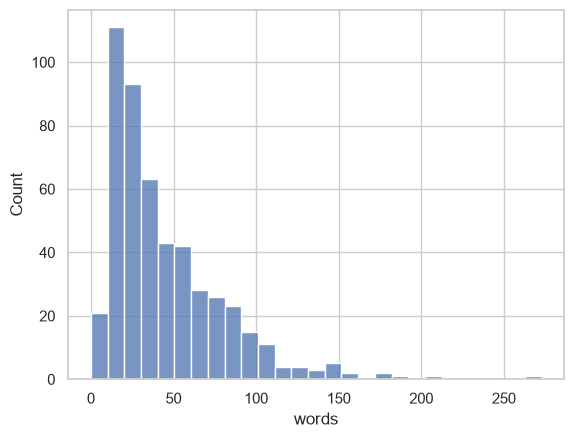

In [22]:
sns.histplot(df, x='words')

`bins`는 몇 칸으로 나눌지를 정한다. 먼저 10칸이다. 칸이 너무 적으면 모양이 뭉개진다.

이 셀과 다음 셀은 **따로** 실행한다. 두 줄을 한 셀에 두면 한 그림 위에 겹쳐 그려진다.

<Axes: xlabel='words', ylabel='Count'>

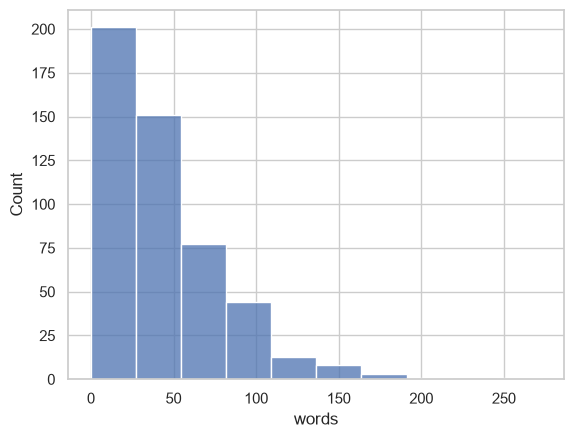

In [23]:
sns.histplot(df, x='words', bins=10)

이번에는 60칸이다. 칸이 너무 많으면 들쭉날쭉해진다.

**같은 자료로 다른 인상**을 줄 수 있으니, 논문에 실을 때는 `bins`를 적어 둔다.

<Axes: xlabel='words', ylabel='Count'>

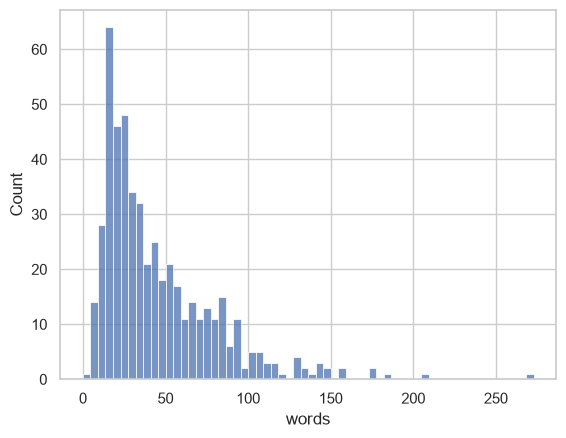

In [24]:
sns.histplot(df, x='words', bins=60)

**상자그림**은 다섯 수치 요약을 그림으로 옮긴 것이다.

- 상자의 양 끝이 Q1(20)과 Q3(61), 가운데 선이 중앙값(33)이다.
- 수염은 상자 폭의 1.5배까지 뻗고, 그 바깥의 점은 **이상치**로 따로 찍는다.
- 오른쪽 끝의 외딴 점(273단어)이 186번 `PEAS`다.

<Axes: xlabel='words'>

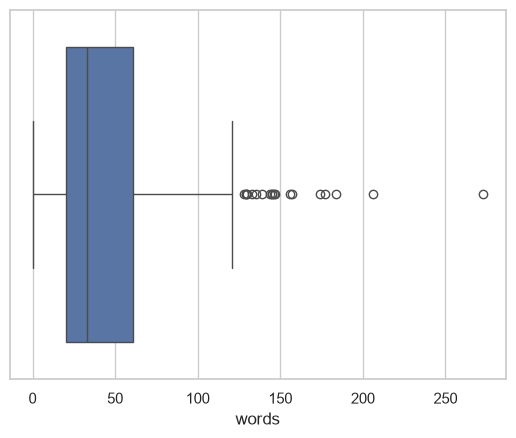

In [25]:
sns.boxplot(df, x='words')

`y`에 범주 열(`book`)을 주면 집단마다 상자가 하나씩 생긴다.

- 첫 줄은 권별 **중앙값**을 구해 작은 순으로 세우고, 그 순서대로 권 이름(`.index`)만 꺼낸다.
- `order=order`: 상자를 이 순서로 세운다. 자모순이 아니라 **값의 순서**로 세워야 견주기 쉽다.
- `x`에 수치, `y`에 범주를 주어 가로로 눕히면 긴 권 이름이 들어간다.

IV권의 상자는 통째로 오른쪽에 있고, 대부분의 권은 상자가 겹친다. 앞의 `groupby` 표와 같은 자료지만, 그림은 권끼리의 차이가 흩어짐보다 큰지까지 보여 준다.

<Axes: xlabel='words', ylabel='book'>

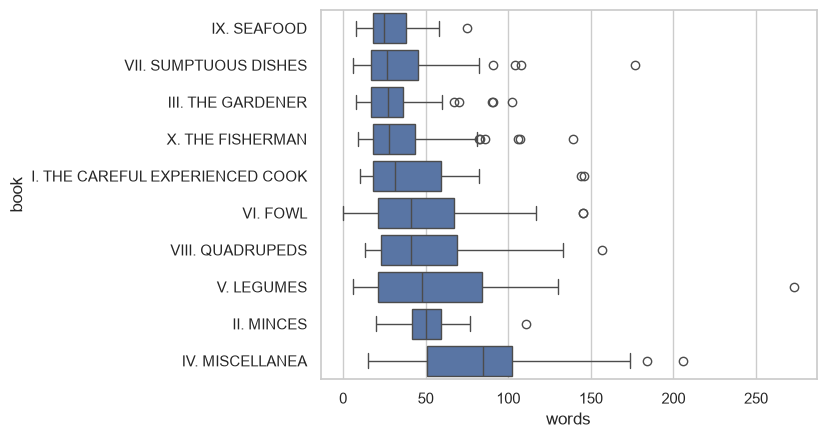

In [26]:
order = df.groupby('book')['words'].median().sort_values().index
sns.boxplot(df, x='words', y='book', order=order)

## 7. 관계 그리기

**산점도**는 두 변수의 관계를 점으로 그린다. 5강에서 구한 $r=-0.14$를 눈으로 본다.

- `names=['freq', 'word']`: `word-freq.txt`는 머리글이 없어서 열 이름을 직접 준다.
- `sep=r'\s+'`: 공백 하나 이상으로 나눈다. 줄 앞의 공백도 알아서 넘긴다. `r'…'`는 역슬래시를 글자 그대로 두는 문자열이다.
- `wf['word'].str.len()`: 단어마다 글자 수를 새 열 `length`로 만든다.
- `alpha=.4`: 점을 반투명하게 그린다. 겹친 자리가 진해져 밀도가 보인다.

`AND`(1,265)와 `THE`(1,009) 두 점 때문에 나머지가 바닥에 깔려 버렸다. 세로축을 로그로 바꾸려면 **같은 셀** 끝에 `plt.gca().set_yscale('log')`를 덧붙인다. 층층이 쌓인 구조가 드러난다.

<Axes: xlabel='length', ylabel='freq'>

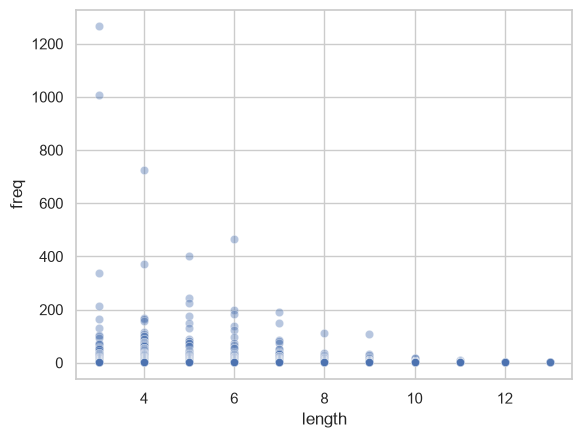

In [27]:
wf = pd.read_csv('data/apicius/word-freq.txt', sep=r'\s+',
                 names=['freq', 'word'])
wf['length'] = wf['word'].str.len()
sns.scatterplot(wf, x='length', y='freq', alpha=.4)

`barplot`은 `x`의 값마다 `y`의 **평균**을 막대로 그린다. 길이별 평균 빈도(3글자 37.32회, 10글자 2.22회)가 한 줄로 나온다.

막대 위의 검은 선은 seaborn이 자동으로 계산한 95% 신뢰구간이다. 부트스트랩으로 구하므로 실행할 때마다 조금씩 달라진다.

**그런데 이 그림을 믿어도 될까?** 3글자 단어 130개 가운데 112개(86%)가 평균 37.32보다 적다. 평균을 끌어올린 것은 `AND`와 `THE` 두 단어다. 평균 막대는 퍼짐도, 막대마다 단어가 몇 개인지도 감춘다.

<Axes: xlabel='length', ylabel='freq'>

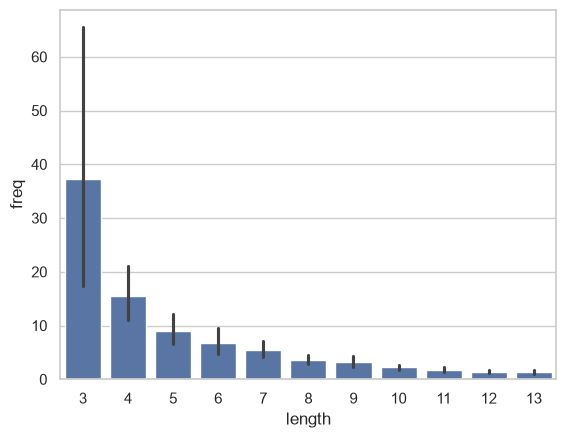

In [28]:
sns.barplot(wf, x='length', y='freq')

같은 자료를 상자그림으로 다시 그린다. 빈도는 한쪽으로 몰려 있으니 `log_scale=True`로 세로축을 로그로 둔다.

길이가 늘수록 중앙값이 6, 3, 2, 2, 1…로 내려간다. 평균 막대보다 Zipf의 약어 법칙이 오히려 또렷하다.
막대는 개수·합계·비율처럼 0이 뜻을 가지는 양에 쓰고, 평균 같은 요약값이나 치우친 자료는 퍼짐이 보이는 그림으로 그린다.

<Axes: xlabel='length', ylabel='freq'>

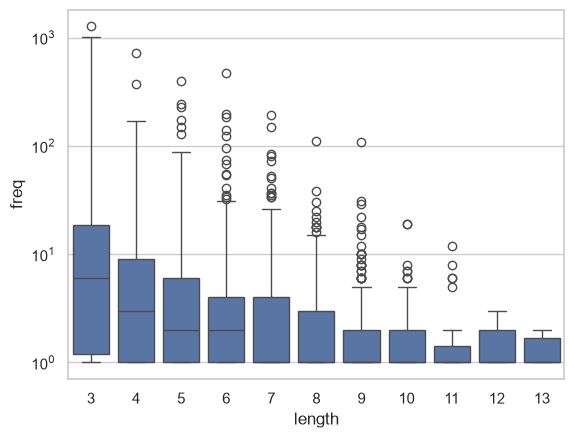

In [29]:
sns.boxplot(wf, x='length', y='freq', log_scale=True)

`hue`에 열 이름을 주면 그 값마다 색을 나누고 범례를 붙인다. 한 그림 안에서 집단을 갈라 본다.

- `wf['freq'] == 1`: 한 번만 나온 단어(단발어)인지를 `True`/`False` 열 `hapax`로 만든다.
- `discrete=True`: 길이가 정수이므로 값 하나에 막대 하나를 그린다.
- `multiple='dodge'`: 두 집단의 막대를 나란히 세운다. `shrink=.8`은 막대 폭을 80%로 줄여 사이를 띄운다.

6글자까지는 파란 막대(`False`), 곧 **되풀이되는 말**이 많다. 7글자에서 거의 같아지고(187 대 188), 그보다 길면 주황 막대(`True`), 곧 **딱 한 번 쓰인 말**이 더 많다.

<Axes: xlabel='length', ylabel='Count'>

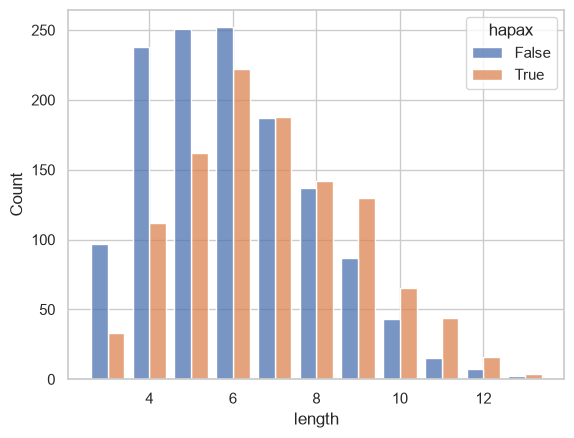

In [30]:
wf['hapax'] = wf['freq'] == 1
sns.histplot(wf, x='length', hue='hapax', discrete=True,
             multiple='dodge', shrink=.8)

그림으로 본 것을 수로 확인한다. `groupby`에 참/거짓 열을 주면 두 집단의 평균 길이가 한 번에 나온다.

단발어는 평균 6.88글자, 그 밖의 단어는 6.01글자다. 6강의 "100번 이상 나온 단어 4.72글자 대 한 번 나온 단어 6.88글자"가 이제 분포로 보인다. 그림을 그린 뒤에는 반드시 수로 확인한다.

In [31]:
print(wf.groupby('hapax')['length']
        .mean().round(2))

hapax
False    6.01
True     6.88
Name: length, dtype: float64


## 8. 그림 남기기

노트북 안의 그림은 커널을 다시 켜면 사라진다. 남길 그림은 **파일로 저장**하고 커밋한다. 먼저 **터미널**에서 담을 폴더를 만든다. 없으면 `FileNotFoundError`가 난다.

```bash
mkdir -p plots
```

- `ax`: seaborn이 돌려주는 **그림틀**(Axes). 여기에 대고 손질한다.
- `ax.set_xlabel`, `ax.set_title`: 축 이름과 제목을 바꾼다.
- `dpi=150`: 해상도. 발표 자료나 논문에는 150 이상을 쓴다.
- `bbox_inches='tight'`: 그림 둘레의 빈 자리를 잘라 준다.

축 이름을 한글로 적으면 matplotlib의 기본 글꼴에 한글이 없어 네모로 나온다. 당장은 영어로 둔다. 한글 이름표가 꼭 필요해지는 것은 10강이다.

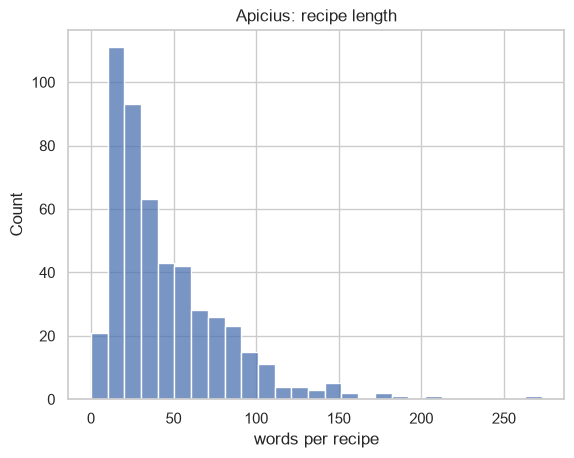

In [32]:
ax = sns.histplot(df, x='words')
ax.set_xlabel('words per recipe')
ax.set_title('Apicius: recipe length')
plt.savefig('plots/words-hist.png', dpi=150, bbox_inches='tight')